# 03 — Evaluation
Run inference and compute metrics for any model (baseline or LoRA) using `scripts/eval.py` and `scripts/metrics.py`.
Change `MODEL_KEY` and `MODE` to evaluate a different model.

In [ ]:
# ── Colab setup (skip if running locally) ──────────────────────────────────
import os
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    # Update this path if your outputs folder is elsewhere
    OUTPUT_BASE = '/content/drive/MyDrive/slm_logic_hardening/outputs'
    !pip install -q transformers datasets pyyaml sentencepiece
    # Navigate directly to your existing project folder in Drive
    %cd '/content/drive/MyDrive/slm_logic_hardening'
else:
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path().resolve()))
    OUTPUT_DIR = 'outputs'

Mounted at /content/drive
/content/drive/MyDrive/slm_logic_hardening


In [ ]:
import torch
device = 'mps' if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## Configuration — change here to switch model

In [ ]:
from pathlib import Path

# ── Pick ONE experiment block below ─────────────────────────────────────────
# To run an experiment: uncomment its 5 lines, comment out all other blocks.

# ── Phi-3.5 | Baseline ──────────────────────────────────────────────────────
# MODEL_KEY     = 'phi35'
# MODE          = 'baseline'
# ADAPTER_PATH  = None
# EXPERIMENT_ID = 'phi35_baseline'
# USE_COT       = False

# ── Phi-3.5 | Baseline + CoT ─────────────────────────────────────────────────
MODEL_KEY     = 'phi35'
MODE          = 'baseline'
ADAPTER_PATH  = None
EXPERIMENT_ID = 'phi35_baseline_cot'
USE_COT       = True

# ── Phi-3.5 | LoRA (FOLIO only) ─────────────────────────────────────────────
# MODEL_KEY     = 'phi35'
# MODE          = 'lora'
# ADAPTER_PATH  = f'{OUTPUT_BASE}/phi35/phi35_lora_folio/final_adapter'
# EXPERIMENT_ID = 'phi35_lora_folio'
# USE_COT       = False

# ── Phi-3.5 | LoRA (FOLIO + ProofWriter 2k) ─────────────────────────────────
# MODEL_KEY     = 'phi35'
# MODE          = 'lora'
# ADAPTER_PATH  = f'{OUTPUT_BASE}/phi35/phi35_lora_folio_pw/final_adapter'
# EXPERIMENT_ID = 'phi35_lora_folio_pw'
# USE_COT       = False

# ── LLaMA-3 8B | Baseline ────────────────────────────────────────────────────
# MODEL_KEY     = 'llama8b'
# MODE          = 'baseline'
# ADAPTER_PATH  = None
# EXPERIMENT_ID = 'llama8b_baseline'
# USE_COT       = True

# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path(OUTPUT_BASE) / MODEL_KEY / EXPERIMENT_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}  |  CoT: {USE_COT}')


Output dir: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_baseline_cot  |  CoT: True


## 1. Run inference

In [ ]:
import yaml
import torch
from scripts.eval import evaluate, load_eval_config

eval_config = load_eval_config('configs/eval/default.yml')

evaluate(
    model_key=MODEL_KEY,
    mode=MODE,
    adapter_path=ADAPTER_PATH,
    eval_config=eval_config,
    output_dir=OUTPUT_DIR,
    experiment_id=EXPERIMENT_ID,
    cot=USE_COT,
)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

folio_v2_train.jsonl: 0.00B [00:00, ?B/s]

...

Generating validation split:   0%|          | 0/203 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]


Evaluating [phi35_baseline_cot]: 100%|██████████| 203/203 [30:35<00:00,  9.04s/it]



PERFORMANCE SUMMARY
  Device:              cuda
  Total time:          1835.89 sec
  Peak GPU/MPS memory: 7650.6 MB
  CPU RAM:             3052.1 MB
  Throughput:          0.111 samples/sec
  Avg latency:         9036.21 ms/example
  Min / Max latency:   3383.51 / 22482.63 ms
Performance stats saved to /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_baseline_cot/performance.json

EM Accuracy: 60.10%
Correct: 122 / 203
Invalid predictions: 0
Results saved to /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_baseline_cot/results.json


In [ ]:
## 2. Classification report + confusion matrix

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from scripts.metrics import build_classification_and_confusion_report, build_deductive_consistency

results_path = OUTPUT_DIR / 'results.json'
with open(results_path) as f:
    data = json.load(f)

results = data['results']
print(f'Model: {data["model_id"]}  |  Mode: {data["mode"]}  |  Accuracy: {data["accuracy"]:.2f}%')

metrics = build_classification_and_confusion_report(results)

Model: microsoft/Phi-3.5-mini-instruct  |  Mode: baseline  |  Accuracy: 60.10%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        True       0.68      0.69      0.68        72
       False       0.66      0.50      0.57        62
   Uncertain       0.50      0.59      0.54        69

    accuracy                           0.60       203
   macro avg       0.61      0.60      0.60       203
weighted avg       0.61      0.60      0.60       203


CONFUSION MATRIX (rows=actual, cols=predicted):
           True  False  Uncertain
True         50      4         18
False         8     31         23
Uncertain    16     12         41


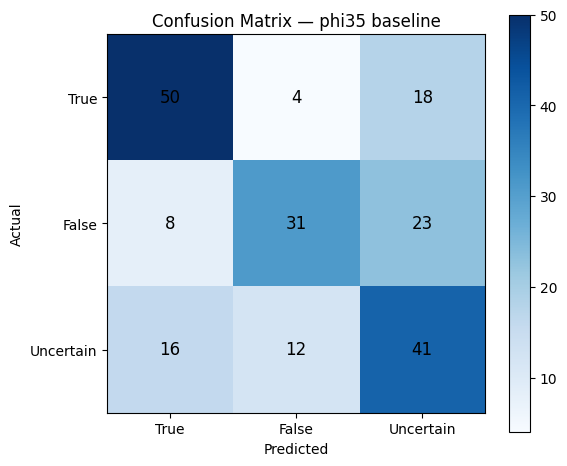

In [ ]:
# Plot confusion matrix heatmap
import numpy as np

labels = ['True', 'False', 'Uncertain']
cm = np.array(metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {MODEL_KEY} {MODE}')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 3. Deductive consistency


DEDUCTIVE CONSISTENCY (accuracy by premise count):
  Premises 1-2:  Accuracy 81.8%  (9/11)
  Premises 3-4:  Accuracy 74.2%  (23/31)
  Premises 5+:  Accuracy 55.9%  (90/161)


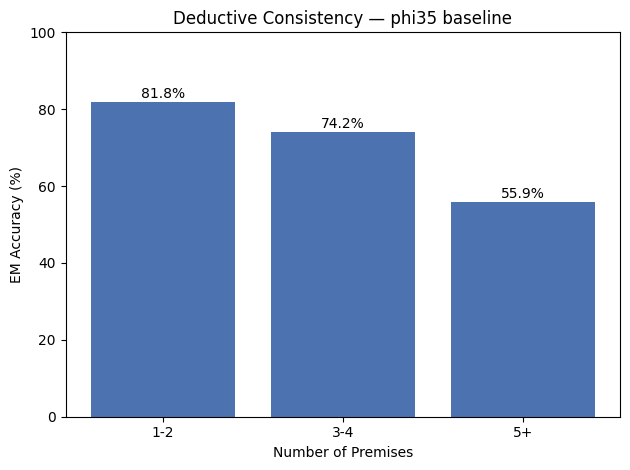

In [ ]:
consistency = build_deductive_consistency(results)

bins = list(consistency.keys())
accs = [consistency[b]['accuracy'] for b in bins]

plt.bar(bins, accs, color='#4C72B0')
plt.ylim(0, 100)
plt.title(f'Deductive Consistency — {MODEL_KEY} {MODE}')
plt.xlabel('Number of Premises')
plt.ylabel('EM Accuracy (%)')
for i, (b, a) in enumerate(zip(bins, accs)):
    plt.text(i, a + 1, f'{a:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deductive_consistency.png', dpi=150)
plt.show()

## 4. Save metrics.json

In [ ]:
from scripts.metrics import run_metrics
run_metrics(str(results_path))
print('Done.')


Experiment: phi35_baseline_cot
Model:      microsoft/Phi-3.5-mini-instruct
Prompting:  cot
Accuracy:   60.09852216748769%  (122/203)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        True       0.68      0.69      0.68        72
       False       0.66      0.50      0.57        62
   Uncertain       0.50      0.59      0.54        69

    accuracy                           0.60       203
   macro avg       0.61      0.60      0.60       203
weighted avg       0.61      0.60      0.60       203


CONFUSION MATRIX (rows=actual, cols=predicted):
           True  False  Uncertain
True         50      4         18
False         8     31         23
Uncertain    16     12         41

DEDUCTIVE CONSISTENCY (accuracy by premise count):
  Premises 1-2:  Accuracy 81.8%  (9/11)
  Premises 3-4:  Accuracy 74.2%  (23/31)
  Premises 5+:  Accuracy 55.9%  (90/161)

Metrics saved to /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_baseline_cot/metrics.